# Nouveau modèle (réunion du 11/07)

Ce notebook est centré sur le nouveau modèle proposé lors de la réunion du 11/07, avec Florence, Gabriel et Olivier

### <span style="color:red">nouveau modèle</span> suggéré par Olivier et Oana
$S(t)$ variable qui modélise l'état inflammatoire résultant de l'injection du signal immun et de l'activation des chimiokines dans les macrophages lining et les fibroblastes. 

L'état inflammatoire  $S(t)$ est renforcé par les neutrophiles N et inhibés par les  macrophages SL-TRM T.

L'inflammation fait croître davantage les neutrophiles (facteur $\alpha$), elle fait croître les momac (facteur $\beta$) et elle fait décroître les SL-TRM (facteur $\gamma$)

**On ne suit plus la population de fibroblastes, mais plutôt la population de neutrophiles qui sont appelés par les chimiokines inflammatoires.**

N(t) : population de <span style="color:red">neutrophiles</span>

M(t) : population de Momac

T(t) : population de macrophages SL-TRM

$$ \begin{aligned}
\frac{dS}{dt} &=& \color{red}{(a\, N - b\,T)} & \, S & \\
\frac{dN}{dt} &=& \alpha \, S\,N &-\delta_N\,N\cdot (N-1)& \\
\frac{dM}{dt} &=&  \beta\,\color{red} {\, S} &&-\delta_M\, M\cdot (M-1) \\
\frac{dT}{dt} &=&-\gamma S\, T & &+\delta_M\,M\cdot (1-T)
\end{aligned}
$$

```mermaid
flowchart LR
    subgraph "Modèle 4 compartiments"
        S["Signal immun inflammatoire"]
        N["Neutrophiles"]
        M["Momac (Monocytes/Macrophages)"]
        T["SL-TRM Macrophages"]
    end

    N -- "renforce (a)" --> S
    T -- "inhibe (b)" --> S
    S -- "croissance (α)" --> N
    S -- "croissance (β)" --> M
    S -- "décroissance (γ)" --> T
    N -- "destruction (δ_N)" --> N
    M -- "destruction (δ_M)" --> M
    M -- "conversion (δ_M)" --> T


![Schéma du modèle](/home/pascal/imagcloud/IMMUN4CURE/brain-storming/schema_mermaid.png)

## 1. Importer les bibliothèques nécessaires

Nous importons numpy, matplotlib.pyplot, scipy.integrate.solve_ivp, et ipywidgets pour les simulations et l'interactivité.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, fixed

## 2. Définir le système différentiel du nouveau modèle

La fonction `system_adim_oliv` implémente les équations différentielles du modèle adimensionné avec neutrophiles, Momac, SL-TRM et signal inflammatoire, selon la proposition d'Olivier et Oana.

In [2]:
def system_adim_oliv(t, y, alpha, beta, gamma, delta_N, delta_M, a, b):
    """
    y : vecteur (S N M T) 
    S : signal inflammatoire adimensionné
    N : Neutrophiles adimensionnés
    M : Monocytes Macrophages  adimensionnés
    T : SL-TRM Macrophages adimensionnés

    la valeur d'équilibre physiologique des neutrophiles est 1
    la valeur d'équilibre physiologique des Momac est 1
    la valeur d'équilibre physiologique des SL-TRM est 1
    alpha <1 est le taux de croissance des neutrophiles causé par l'inflammation
    beta  est le taux de croissance des Momac causé par l'inflammation
    gamma est le taux de destruction des SL-TRM causé par l'inflammation 
    delta_N est le taux de destruction des neutrophiles
    delta_M est le taux de conversion  Momac -> SL-TRM  
    """

    S, N, M, T = y

    dSdt =  (a* N - b* T)*S
    dNdt = alpha * S*N - delta_N * N * (N-1)
    dMdt = beta *S - delta_M * M*(M-1)
    dTdt = -gamma * S * T + delta_M *M *(1-T)

    return [dSdt, dNdt, dMdt, dTdt]

## 3. Définir la fonction de simulation

La fonction `inflam_adim_oliv` résout le système différentiel et trace les résultats pour visualiser l'évolution des différentes populations et du signal inflammatoire.

In [3]:
def inflam_adim_oliv(y0, alpha, beta, gamma, delta_N, delta_M, a, b, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_oliv, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/1000), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, a, b))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(321)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('signal inflammatoire')

    plt.subplot(322)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.title('neutrophiles')

    plt.subplot(323)
    plt.plot(t,M, 'g')
    plt.xlabel('temps ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.title('monocytes macrophages')

    plt.subplot(324)
    plt.plot(t,T, 'm')
    plt.xlabel('temps ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.title('macrophages SL-TRM')

    plt.subplot(325)
    plt.plot(M,T, 'm')
    plt.xlabel('Momac')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.figtext(0.3, 0.01, 'Plan de phase entre Momac et SL-TRM ', ha='center', fontsize=12)

    plt.subplot(326)
    plt.plot(S,T, 'm')
    plt.xlabel('signal inflammatoire')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.figtext(0.7, 0.01, 'Plan de phase entre inflammation et SL-TRM ', ha='center', fontsize=12)

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

## 4. Exécuter une simulation de base avec inflam_adim_oliv

On observe le comportement du modèle avec des paramètres standards.

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


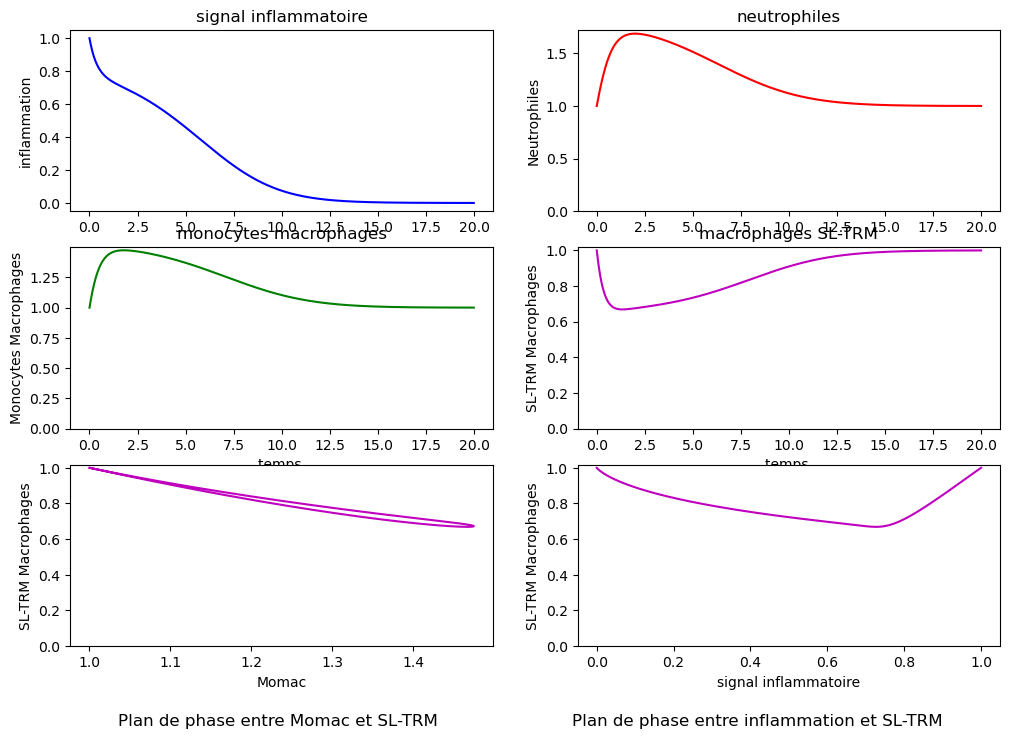

In [4]:
inflam_adim_oliv([1, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=1, duree=20)

## 5. Tester la stabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est stable (par exemple, a + b > seuil).

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


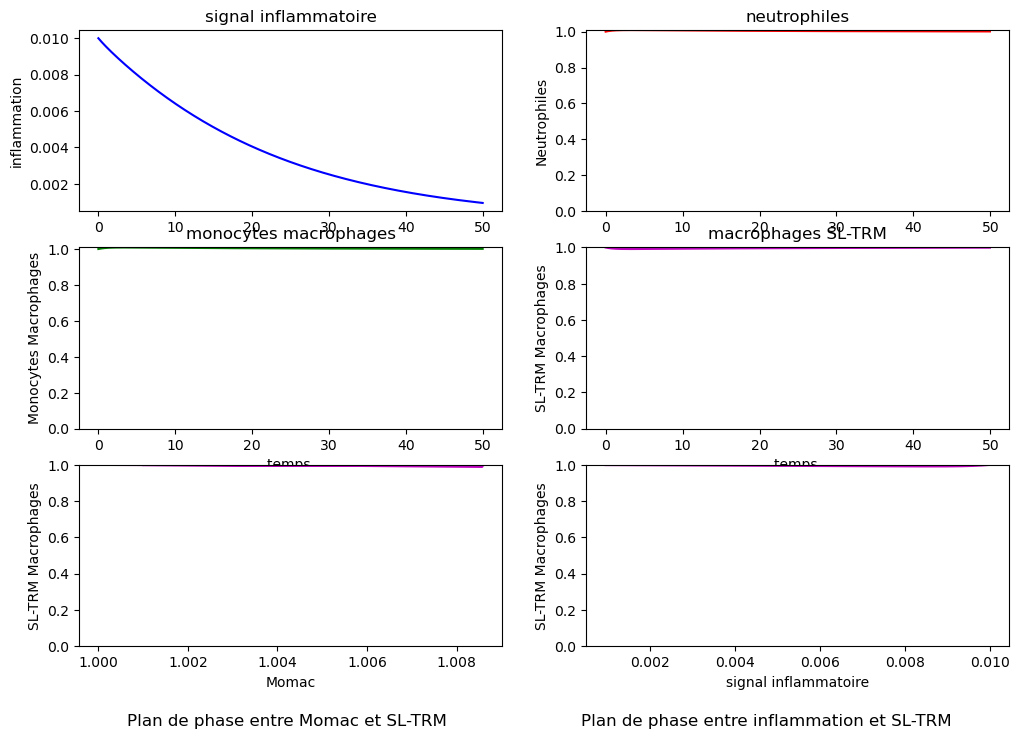

In [5]:
#l'équilibre physiologique est stable si a + b > seuil
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=0.40, duree=50)

## 6. Tester l’instabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est instable (par exemple, a + b < seuil).

valeurs finales: Signal=0.553, Neutrophiles=1.480, Momac=1.359, SL-TRM=0.730


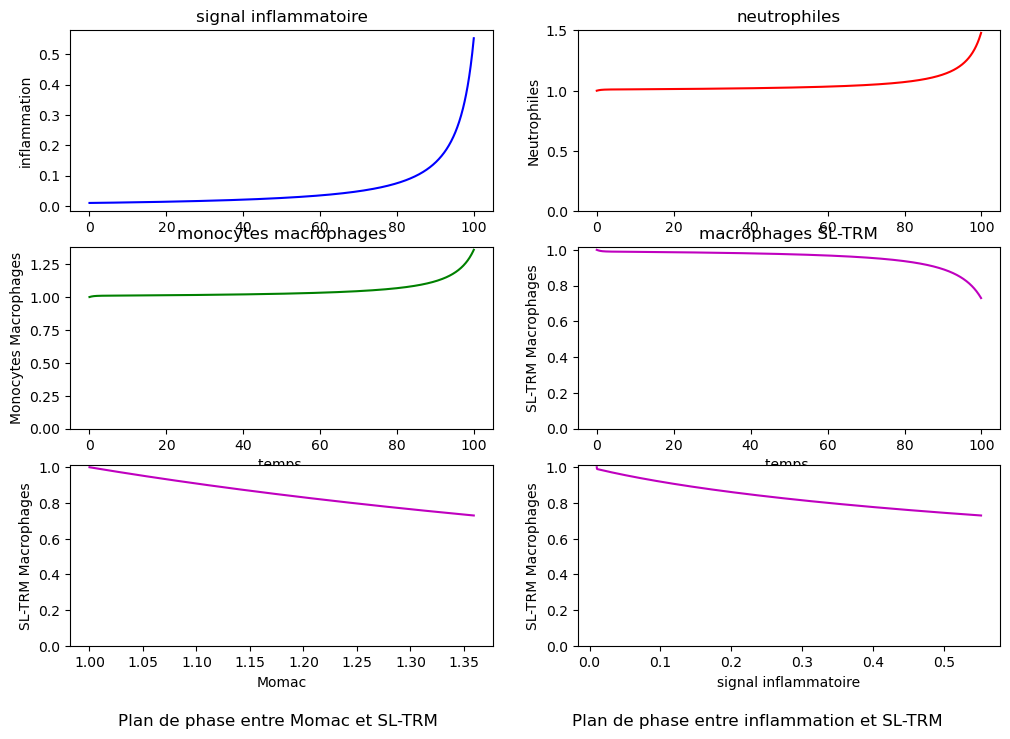

In [6]:
#l'équilibre physiologique est instable si a + b < seuil
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.31, b=0.30, duree=100)

valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


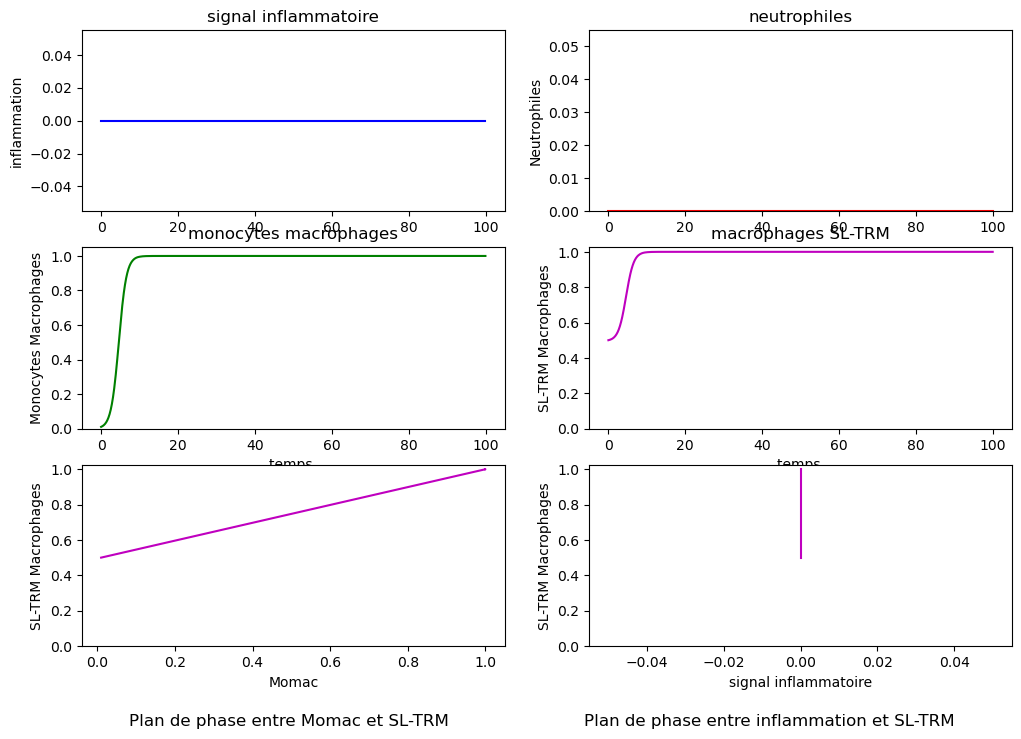

In [7]:
# test 10/10 brain storming pour instabilité des points fixes du type (0,0,0,T) avec T non nul <1
inflam_adim_oliv([0., 0, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


on constate que le système tend vers un autre point fixe $(S,N,M,T)=(0,0,1,1)$

valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


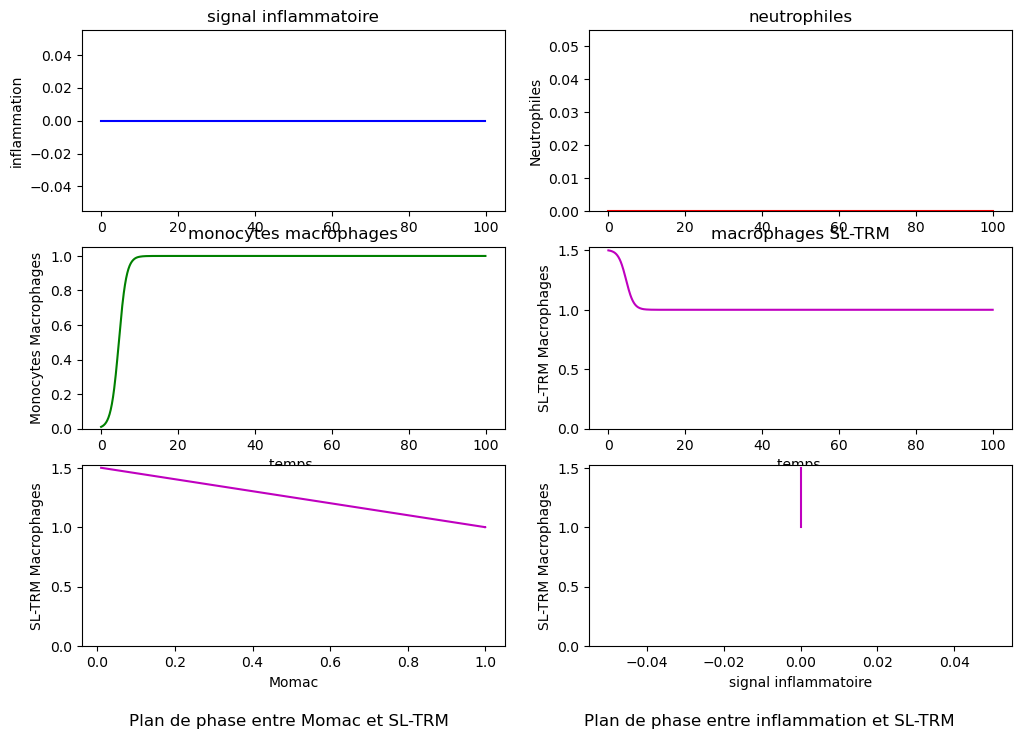

In [8]:
# test pour instabilité des points fixes du type (0,0,0,T) avec T_ini > 1
inflam_adim_oliv([0., 0, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=100)

On constate que  le système revient encore vers un autre point fixe $(S,N,M,T)=(0,0,1,1)$

Il semble qu'il y ait une sous-variété invariante $\{0\}\times \{0\}\times \mathbb{R}\times\mathbb{R}$

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


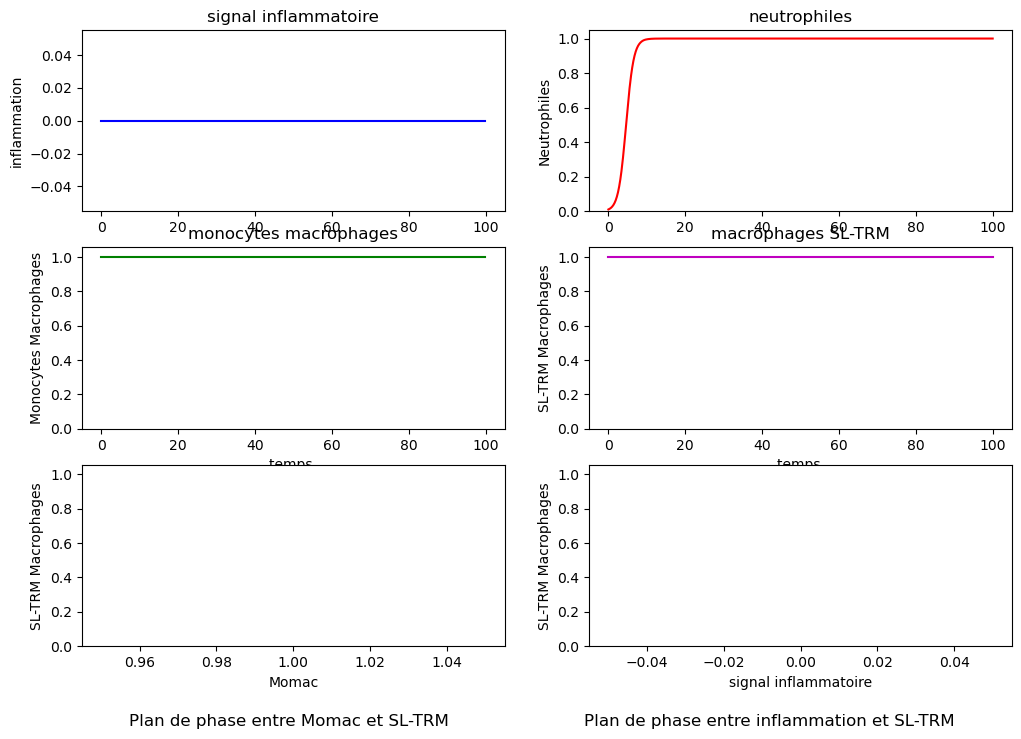

In [9]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_oliv([0., 0.01, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On voit que le système revient encore vers le point fixe $(S,N,M,T)=(0,1,1,1)$

valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


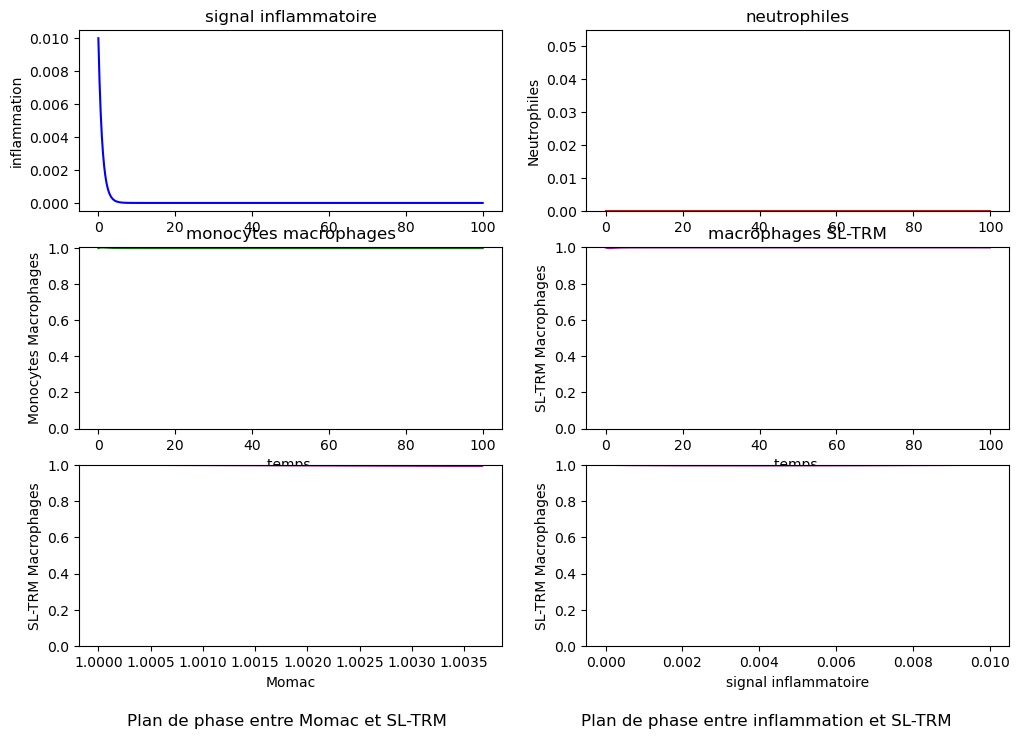

In [10]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_oliv([0.01, 0., 1.0, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On constate que ce point $(0,0,1,1)$ est stable pour les pertubations de $S$ et instable pour les perturbations en $N$.

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


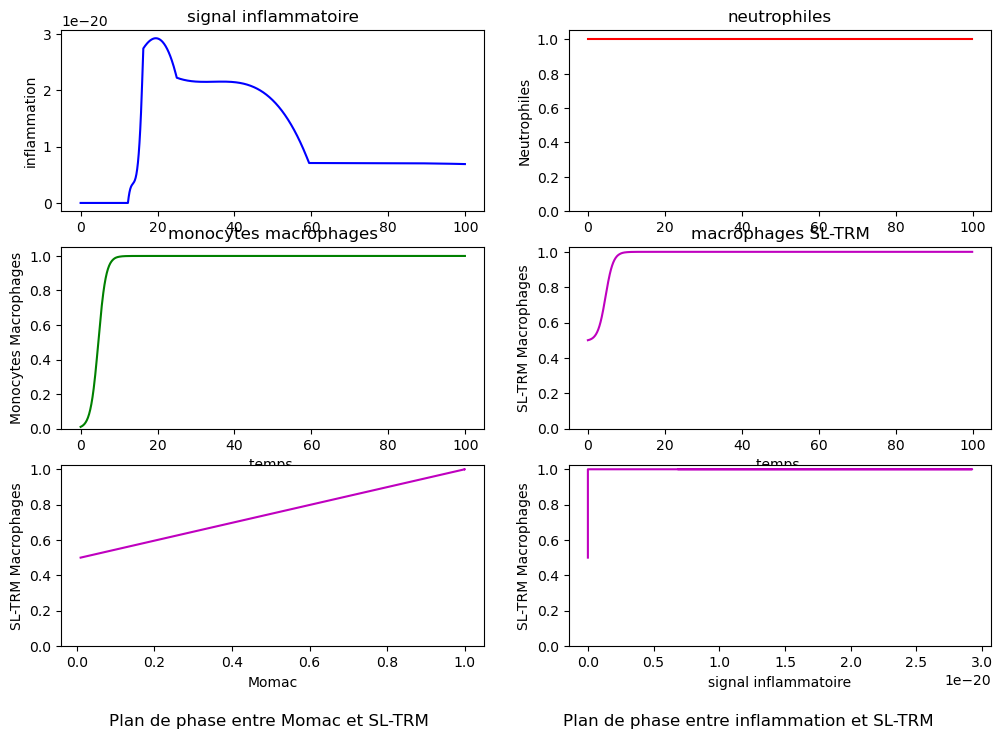

In [11]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,1,0,T) avec T non nul <1
inflam_adim_oliv([0., 1, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On va vers l'état physiologique. 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


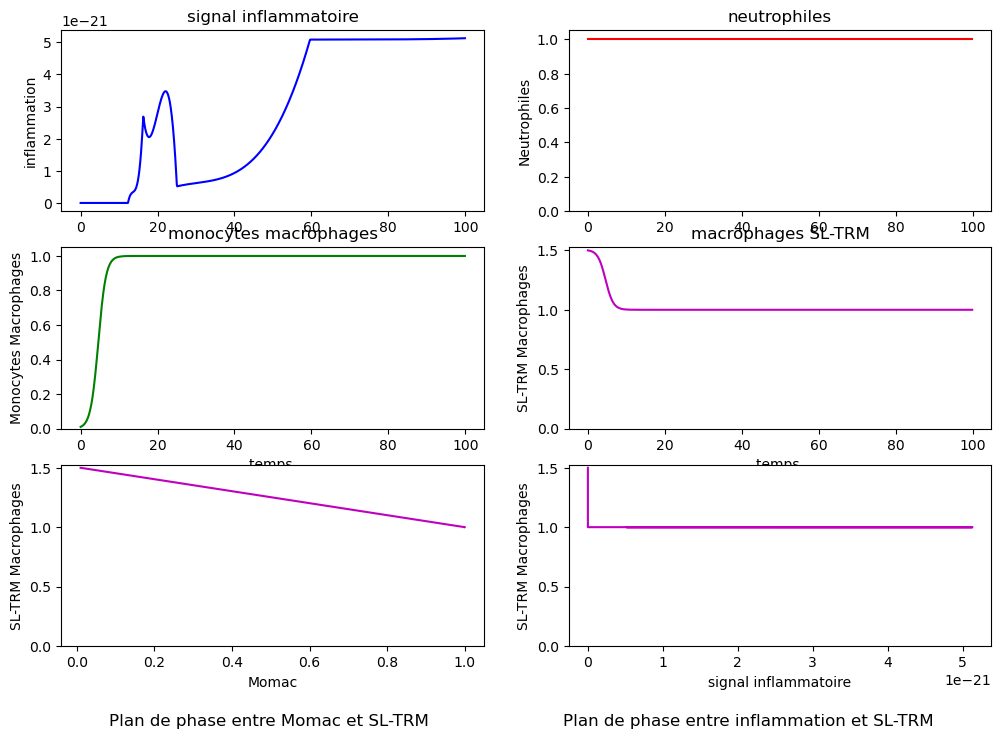

In [12]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini > 1
inflam_adim_oliv([0., 1, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=100)

On remarque un phénomène intéressant: en l'absence de signal immun initial même en présence de Neutrophiles, l'état $(0,1, 0, T)$ évolue vers l'état physiologique.


valeurs finales: Signal=1123.067, Neutrophiles=562.569, Momac=9.574, SL-TRM=0.014


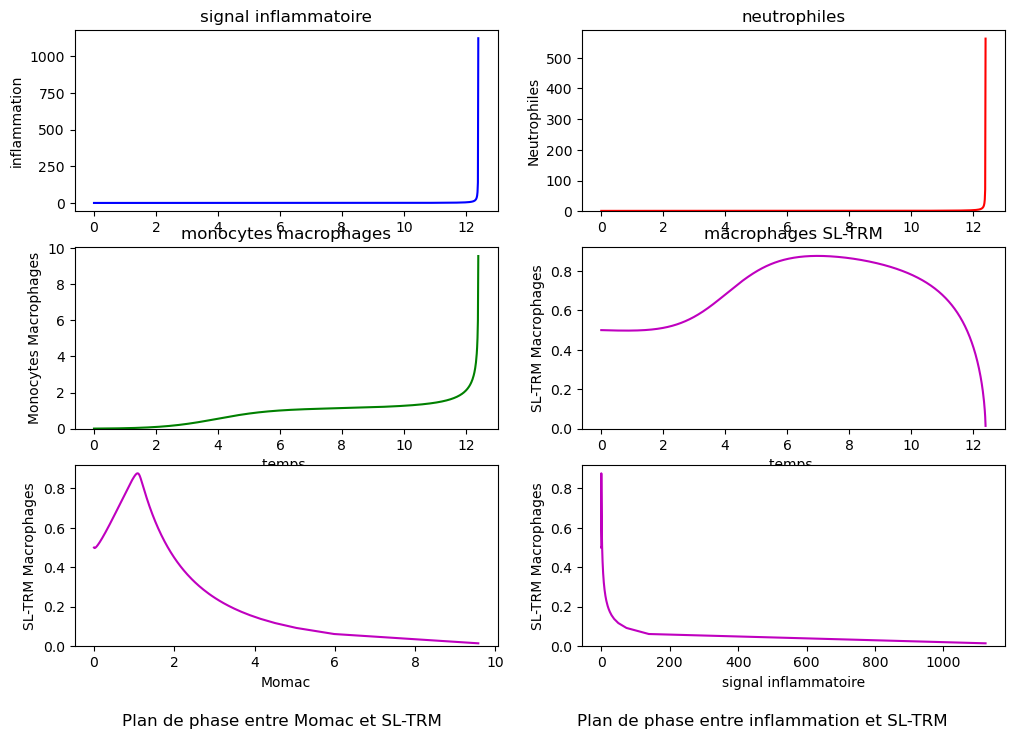

In [13]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini < 1
inflam_adim_oliv([0.01, 1, 0., 0.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=12.5)

On voit un instabilité lorsque le patient a un stock insuffisant de SL-TRM (T) et des neutrophiles.

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


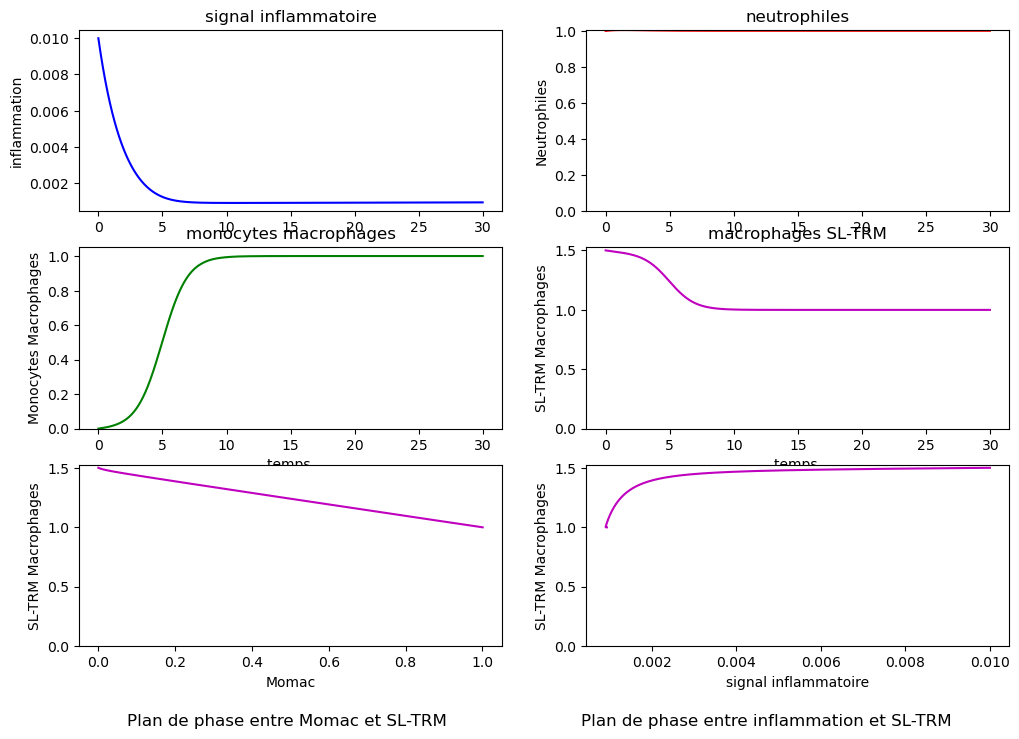

In [14]:
#instabilité des points fixes du type (0,1,0,T) avec T_ini > 1 
inflam_adim_oliv([0.01, 1, 0., 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=30)


On trouve que la sous-variété $T=1$ est critique pour ce type de point fixe. En effet  lorsque $T>1$ le système revient à l'état physiologique. Alors que pour $T<1$ le système s'emballe. La crise s'amplifie

## 7. Créer une interface interactive pour explorer le modèle

Utilisez les curseurs pour explorer dynamiquement l'effet des paramètres sur le modèle.

In [15]:
# Définition de la fonction interactive
def interactive_inflam_oliv(alpha,beta,gamma,delta_N,delta_M, a, b, duree):
    inflam_adim_oliv([1, 1.00, 1, 1],
           alpha, beta, gamma, delta_N, delta_M, a, b, duree)

# Création des curseurs pour les paramètres
ui = widgets.HBox([
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.01, value=1, description='alpha neutrophiles <-signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='beta Momac <- neutrophiles'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='gamma  SL-TRM <- signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_N  neutrophiles'),
    ]),
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_M conversion  Momac -> SL-TRM'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=0.35, description='a feed-back neutrophiles -> signal'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=1, description='b hold-back SL-TRM -> signal'),
        widgets.IntSlider(min=0, max=20, step=1, value=10, description='durée de la simulation'),
    ])
])

out = widgets.interactive_output(
    interactive_inflam_oliv,
    {
        'alpha': ui.children[0].children[0],
        'beta': ui.children[0].children[1],
        'gamma': ui.children[0].children[2],
        'delta_N': ui.children[0].children[3],
        'delta_M': ui.children[1].children[0],
        'a': ui.children[1].children[1],
        'b': ui.children[1].children[2],
        'duree': ui.children[1].children[3],
    }
)

display(ui, out)

Output()

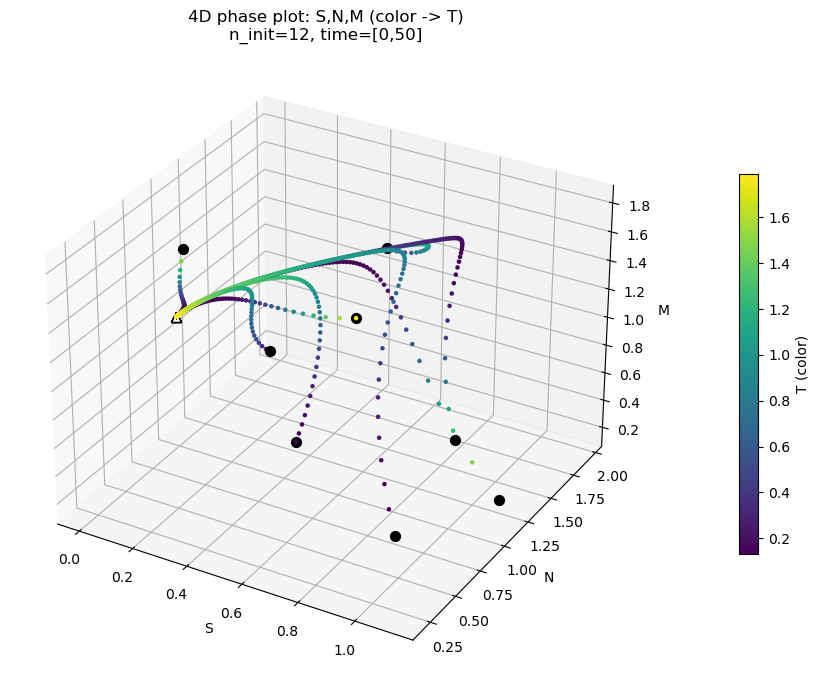

In [16]:
import numpy as np
from scipy.integrate import solve_ivp

# 4D phase-plot via 3D projections + color for the 4th variable
# Uses the already defined `system_adim_oliv` function and available imports (numpy, matplotlib, solve_ivp).
# Place this cell at index 35.

import matplotlib.pyplot as plt

def plot_4d_phase(system_func,
                  params=None,
                  n_trajectories=12,
                  bounds=(0.0, 2.0),
                  duree=20.0,
                  t_steps=300,
                  axes_names=('S','N','M','T'),
                  show_arrows=True,
                  cmap='viridis',
                  figsize=(10,7)):
    """
    Plot trajectories in 3D with the 4th variable encoded as color.
    - system_func : f(t, y, *params) as defined in the notebook (system_adim_oliv)
    - params : tuple/list of parameters passed to system_func (alpha, beta, gamma, delta_N, delta_M, a, b)
               If None, uses a reasonable default.
    - n_trajectories : number of initial conditions sampled in the hypercube
    - bounds : (low, high) for sampling each variable in the hypercube [low, high]^4
    - duree : integration time
    - t_steps : number of time points for t_eval
    - axes_names : names for axes (for labels)
    - show_arrows : mark start and end points of each trajectory
    """
    if params is None:
        params = (1, 1, 1, 1, 1, 0.35, 1)  # alpha, beta, gamma, delta_N, delta_M, a, b

    low, high = bounds
    t_eval = np.linspace(0, duree, t_steps)

    # Sample random initial conditions in the 4D hypercube
    inits = np.random.uniform(low, high, size=(n_trajectories, 4))

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # map axes indices
    axis_idx = {name: i for i, name in enumerate(axes_names)}
    # We'll plot S vs N vs M on the 3D axes and color by T by default.
    x_key, y_key, z_key, color_key = axes_names[0], axes_names[1], axes_names[2], axes_names[3]
    xi, yi, zi, ci = axis_idx[x_key], axis_idx[y_key], axis_idx[z_key], axis_idx[color_key]

    all_cvalues = []
    scatters = []

    for i, y0 in enumerate(inits):
        sol = solve_ivp(system_func, [0, duree], y0, method='Radau', t_eval=t_eval, args=tuple(params))
        if not sol.success:
            continue
        Y = sol.y  # shape (4, len(t_eval))
        X = Y[xi]
        Yv = Y[yi]
        Z = Y[zi]
        C = Y[ci]
        # scatter colored by 4th variable along the trajectory
        p = ax.scatter(X, Yv, Z, c=C, cmap=cmap, s=5, alpha=1)
        scatters.append(p)
        all_cvalues.append(C)
        if show_arrows:
            # mark start and end
            ax.scatter(X[0], Yv[0], Z[0], color='k', marker='o', s=50)
            ax.scatter(X[-1], Yv[-1], Z[-1], color='white', edgecolor='k', marker='^', s=50)

    # colorbar based on concatenated color values
    if len(all_cvalues) > 0:
        allc = np.concatenate(all_cvalues)
        mappable = plt.cm.ScalarMappable(cmap=cmap)
        mappable.set_array(allc)
        cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1)
        cbar.set_label(f'{color_key} (color)')

    ax.set_xlabel(x_key)
    ax.set_ylabel(y_key)
    ax.set_zlabel(z_key)
    ax.set_title(f'4D phase plot: {x_key},{y_key},{z_key} (color -> {color_key})\n'
                 f'n_init={n_trajectories}, time=[0,{duree}]')
    ax.grid(True)
    plt.tight_layout()
    plt.show()


# Example usage with the notebook's system_adim_oliv and typical parameters:
plot_4d_phase(system_adim_oliv,
              params=(1, 1, 1, 1, 1, 0.35, 1),
              n_trajectories=12,
              bounds=(0.0, 2.0),
              duree=50,
              t_steps=500)

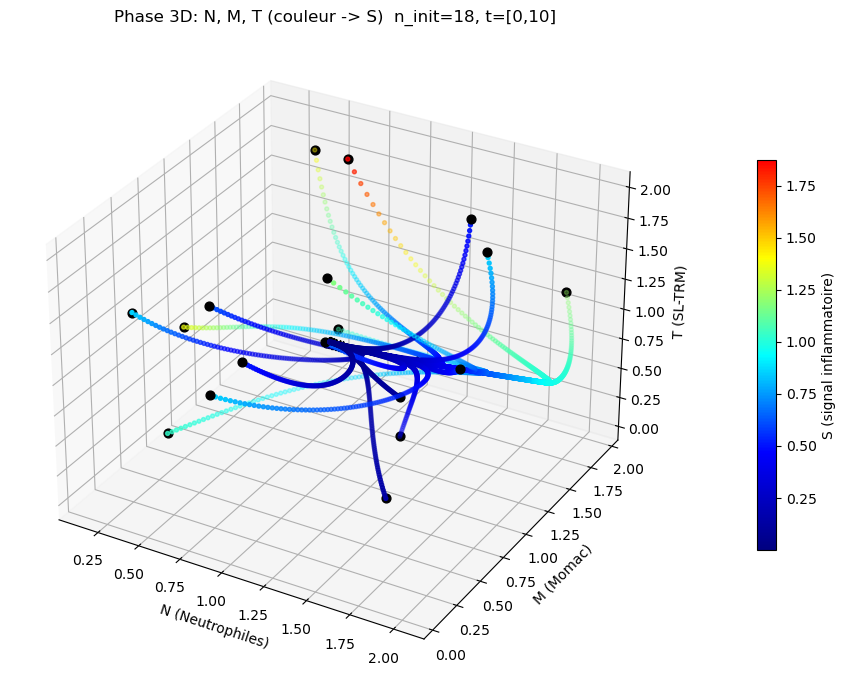

In [37]:
def plot_NMT_color_S(system_func,
                     params=None,
                     n_trajectories=12,
                     bounds=(0.0, 2.0),
                     duree=20.0,
                     t_steps=300,
                     show_arrows=True,
                     cmap_name='blue_red',
                     figsize=(10,7)):
    """
    Trace en 3D les trajectoires sur les axes N (x), M (y), T (z) et colore par S (signal).
    - system_func : f(t, y, *params) (ex: system_adim_oliv)
    - params : tuple (alpha, beta, gamma, delta_N, delta_M, a, b)
    - n_trajectories : nombre d'ICs
    - bounds : (low, high) intervalle d'échantillonnage pour chaque variable initiale
    - duree, t_steps : intégration
    - cmap_name : nom interne pour la cmap créée (navy -> red)
    """
    import matplotlib.colors as mcolors

    if params is None:
        params = (1, 1, 1, 1, 1, 0.35, 1)

    low, high = bounds
    t_eval = np.linspace(0, duree, t_steps)

    # échantillonnage des conditions initiales dans le cube 4D
    inits = np.random.uniform(low, high, size=(n_trajectories, 4))

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # indices: S=0, N=1, M=2, T=3
    xi, yi, zi, ci = 1, 2, 3, 0  # N, M, T axes; couleur = S

    all_cvalues = []

    # construire cmap allant du bleu profond (navy) au rouge
    cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, ['navy', 'blue', 'cyan', 'yellow', 'red'])

    trajs = []
    for y0 in inits:
        sol = solve_ivp(system_func, [0, duree], y0, method='Radau', t_eval=t_eval, args=tuple(params))
        if not sol.success:
            continue
        Y = sol.y
        X = Y[xi]
        Yv = Y[yi]
        Z = Y[zi]
        C = Y[ci]
        trajs.append((X, Yv, Z, C))
        all_cvalues.append(C)

    if len(trajs) == 0:
        print("Aucune trajectoire calculée avec succès.")
        return

    allc = np.concatenate(all_cvalues)
    vmin, vmax = np.min(allc), np.max(allc)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for X, Yv, Z, C in trajs:
        p = ax.scatter(X, Yv, Z, c=C, cmap=cmap, norm=norm, s=8)
        if show_arrows:
            ax.scatter(X[0], Yv[0], Z[0], color='k', marker='o', s=40)            # début
            ax.scatter(X[-1], Yv[-1], Z[-1], color='white', edgecolor='k', marker='^', s=50)  # fin

    # colorbar
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(allc)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1)
    cbar.set_label('S (signal inflammatoire)')

    ax.set_xlabel('N (Neutrophiles)')
    ax.set_ylabel('M (Momac)')
    ax.set_zlabel('T (SL-TRM)')
    ax.set_title(f'Phase 3D: N, M, T (couleur -> S)  n_init={len(trajs)}, t=[0,{duree}]')
    ax.grid(True)
    plt.tight_layout()
    plt.show()


# Exemple d'utilisation :
plot_NMT_color_S(system_adim_oliv,
                 params=(1, 1, 1, 1, 1, 0.3, 1),
                 n_trajectories=20,
                 bounds=(0.0, 2.0),
                 duree=10,
                 t_steps=500)

Il faut étudier avec précision les équilibres et les conditions de stabilité du système.

interface graphique pour trouver les points d'équilibre non triviaux, intersection de la parabole
$$
N^* = 1 + \frac{\alpha \delta_M}{\beta \delta_N} M^* (M^* - 1)
$$
et de l'hyperbole
$$
M^* =  \frac{a \,\gamma \,\delta_N}{b\, \alpha \,\delta_M} \frac{N^* (N^* - 1)}{(1 - \frac{a}{b} N^*)}
=-\frac{\gamma \delta_N}{\alpha \delta_M}  (N^* + b/a -1) + \frac{(b/a)^{2}(1-b/a)}{(N^* - b/a)} 

$$


In [18]:
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

import matplotlib.pyplot as plt

def plot_equilibres(a_b=1.0, alpha_beta=1.0, gamma_alpha=1.0, deltaN_deltaM=1.0):
    # N* range, avoid division by zero
    N = np.linspace(-10, 10, 2000)
    M = np.linspace(-10, 20, 2000)
    
    N_parabole= 1 + (alpha_beta/deltaN_deltaM)*(M - 1)*M
    #M_hyperbole = (a_b*gamma_alpha * deltaN_deltaM * N * (N - 1)) / (1 - a_b*N)

    # Avoid division by zero for N/a_b and N_star/a_b
    # Hyperbole : séparer les deux branches
    N_safe_left = N[N < 1/a_b - 1e-6]
    N_safe_right = N[N > 1/a_b + 1e-6]
    #M_hyperbole_left = (a_b*gamma_alpha * deltaN_deltaM * N_safe_left * (N_safe_left - 1)) / (1 - N_safe_left*a_b)
    #M_hyperbole_right = (a_b*gamma_alpha * deltaN_deltaM * N_safe_right * (N_safe_right - 1)) / (1 - N_safe_right*a_b)
    M_hyperbole_left = -gamma_alpha*deltaN_deltaM*(N_safe_left + 1/a_b -1)+ (1/a_b)**2 *(1- 1/a_b)/(N_safe_left - 1/a_b)
    M_hyperbole_right = -gamma_alpha*deltaN_deltaM*(N_safe_right + 1/a_b -1)+ (1/a_b)**2 *(1- 1/a_b)/(N_safe_right - 1/a_b)
    # tracé
    plt.figure(figsize=(8,6))
    plt.plot(N_parabole, M, label="nullcline N", color='blue')
    plt.plot(N_safe_left, M_hyperbole_left, label="", color='red')
    plt.plot(N_safe_right, M_hyperbole_right, label="nullcline M ", color='red')
    plt.plot(N, (-gamma_alpha * deltaN_deltaM * (N + 1/a_b -1) ), label="oblique asymptote", color='k', linestyle=':', linewidth=1)
    plt.plot((1/a_b)*np.ones_like(M), M, 'k:', label=" vertical asymptote N=b/a")
    plt.xlabel('$N^*$')
    plt.ylabel('$M^*$')
    plt.title(f"Equilibria points\n a/b={a_b:.2f}, α/β={alpha_beta:.2f}, γ/α={gamma_alpha:.2f}, δN/δM={deltaN_deltaM:.2f}")
    plt.ylim(-10, 10)
    plt.xlim(-10, 20)
    plt.legend()
    plt.grid(True)
    #plt.show()

interact(
    plot_equilibres,
    a_b=widgets.FloatSlider(min=0.1, max=10.0, step=0.01, value=1.0, description='a/b'),
    alpha_beta=widgets.FloatSlider(min=0.1, max=10.0, step=0.01, value=1.0, description='α/β'),
    gamma_alpha=widgets.FloatSlider(min=0.1, max=100, step=0.01, value=1.0, description='γ/α'),
    deltaN_deltaM=widgets.FloatSlider(min=0.1, max=10.0, step=0.01, value=1.0, description='δN/δM')
)


interactive(children=(FloatSlider(value=1.0, description='a/b', max=10.0, min=0.1, step=0.01), FloatSlider(val…

<function __main__.plot_equilibres(a_b=1.0, alpha_beta=1.0, gamma_alpha=1.0, deltaN_deltaM=1.0)>

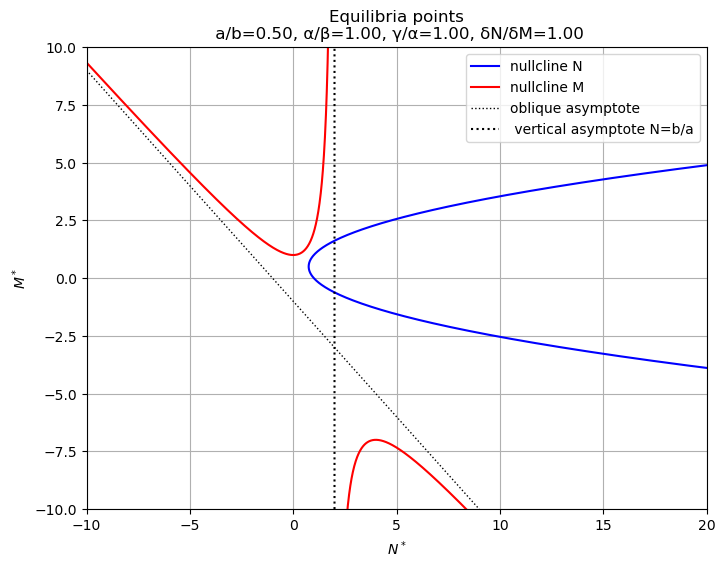

In [19]:
plot_equilibres(a_b=0.5, alpha_beta=1, gamma_alpha=1, deltaN_deltaM=1)
plt.savefig('equilibres.png', format = 'png')

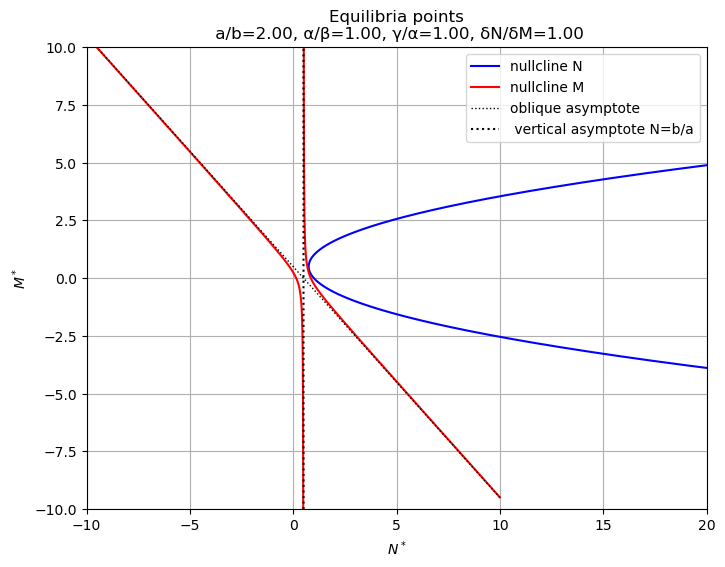

In [20]:
plot_equilibres(a_b=2, alpha_beta=1, gamma_alpha=1, deltaN_deltaM=1 )
plt.savefig('equilibres_1.png', format = 'png')


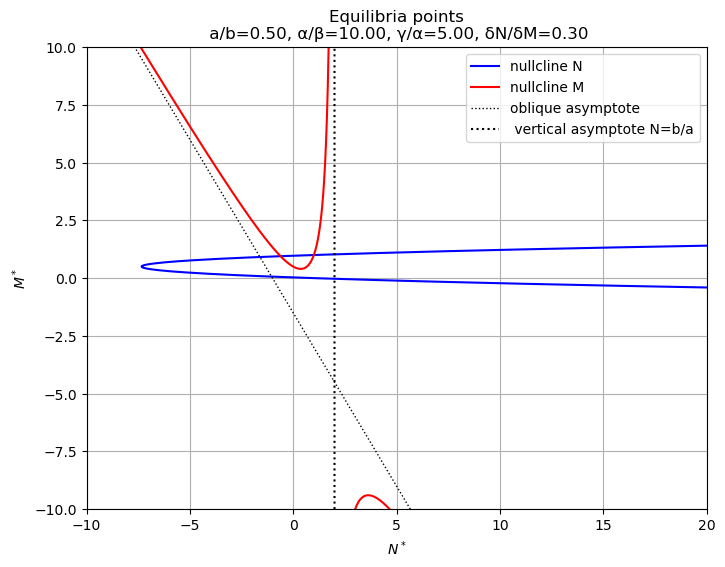

In [21]:
plot_equilibres(a_b=0.5, alpha_beta=10, gamma_alpha=5, deltaN_deltaM=0.3 )
plt.savefig('equilibres_2.png', format = 'png')

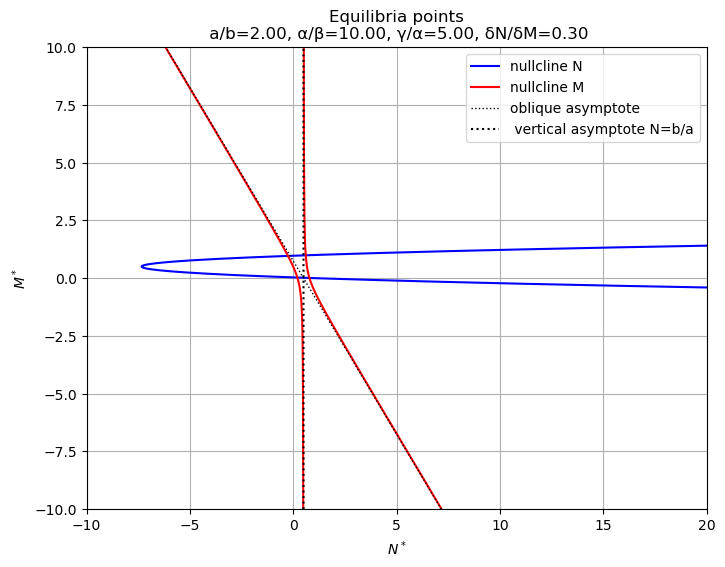

In [22]:
plot_equilibres(a_b=2, alpha_beta=10, gamma_alpha=5, deltaN_deltaM=0.3 )
plt.savefig('equilibres_3.png', format = 'png')

In [23]:
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

import matplotlib.pyplot as plt
def plot_cubics(A=1.0, B=1.0, C=1.0):
    # Example cubic: T**3 + p*T**2 + q*T + r
    T = np.linspace(-0.5, 6, 500)
    p = A *  (1 - B - C) /C # Coefficient for T^2
    q = A  * (2 * B - 1) /C         # Coefficient for T
    r = -A * B / C                   # Constant term
    Y = T**3 + p * T**2 + q * T + r
    # Calculate the discriminant
    s = A*(-A*(B + C - 1)**2 + 3*C*(2*B - 1))/(3*C**2)
    t = A*(-2*A**2*(B + C - 1)**3 + 9*A*C*(2*B - 1)*(B + C - 1) - 27*B*C**2)/(27*C**3)
    Delta = (t/2)**2 + (s/3)**3
    # Calculate roots based on the sign of the discriminant
    if Delta >= 0:
        root = np.cbrt(-t/2 + np.sqrt(Delta)) + np.cbrt(-t/2 - np.sqrt(Delta)) - p/3
        # do not forget to adjust root by -p/3 to get roots of original cubic
    else:
        theta = np.arccos(3*np.sqrt(3)*t/ (2*s*np.sqrt(-s)))
        root = [2 * np.sqrt(-s/3) * np.cos((theta + 2 * k * np.pi)/3) - p/3 for k in range(3)]
        # do not forget to adjust roots by -p/3 to get roots of original cubic

    plt.figure(figsize=(8, 5))
    plt.plot(T, Y, label=f'T³ + {p:.2f}·T² + {q:.2f}·T + {r:.2f}')
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.xlabel('T')
    plt.ylabel('Cubic polynomial')
    plt.title(f"Equilibria points\n  B={B:.2f}, B+C={B+C:.2f}, Δ={Delta:.2f}")
    plt.figtext(0.98, 0.02, f'root={np.round(root, 2)}', ha='right', va='bottom', fontsize=12)
    plt.legend()
    plt.grid(True)
    #plt.show()


In [24]:
interact(
    plot_cubics,
    A=widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='A'),
    B=widgets.FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description='B'),
    C=widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='C')
    
)

interactive(children=(FloatSlider(value=1.0, description='A', max=5.0, min=0.1), FloatSlider(value=1.0, descri…

<function __main__.plot_cubics(A=1.0, B=1.0, C=1.0)>

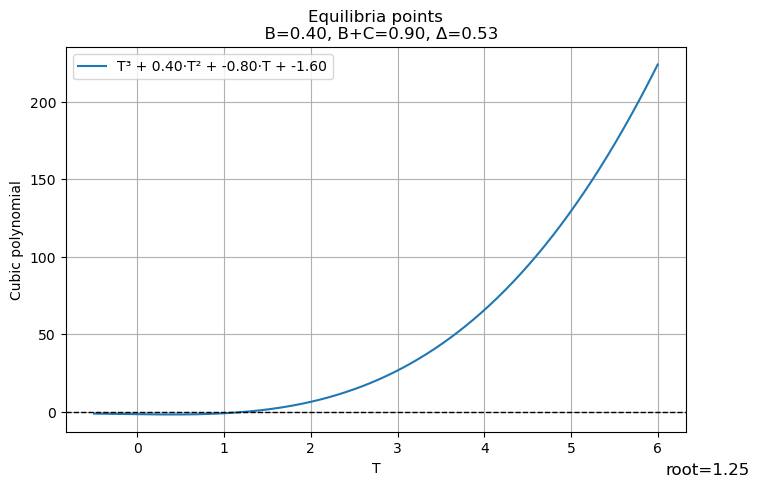

In [25]:
plot_cubics(A=2, B=0.4, C=0.5)
plt.savefig('cubic_1.png', format = 'png')

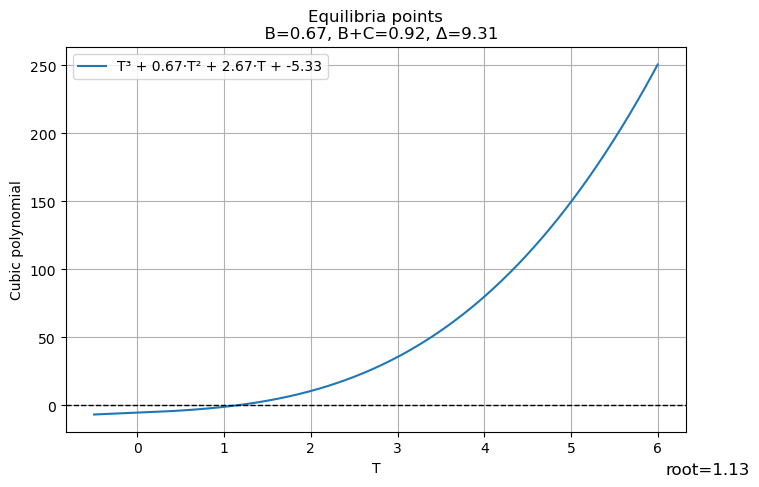

In [26]:
plot_cubics(A=2, B=2/3, C=1/4)
plt.savefig('cubic_2.png', format = 'png')

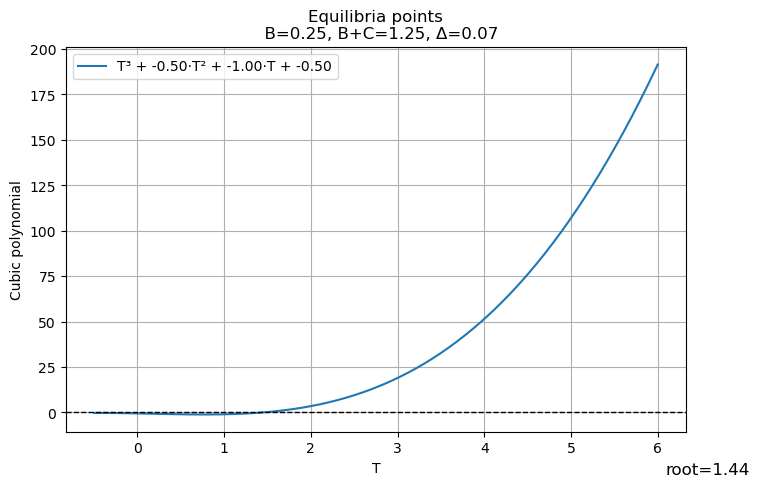

In [27]:
plot_cubics(A=2, B=0.25, C=1)
plt.savefig('cubic_3.png', format = 'png')

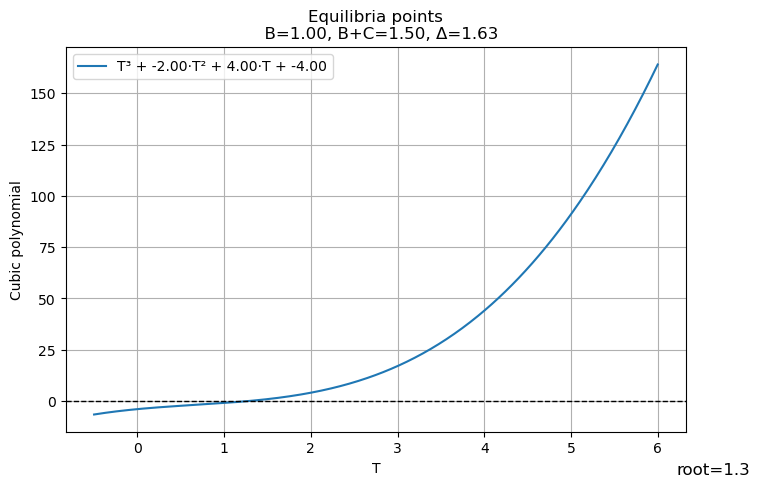

In [28]:
plot_cubics(A=2, B=1, C=0.5)
plt.savefig('cubic_4.png', format = 'png')

In [29]:
import sympy as sp

# Define symbolic variables
A, B, C = sp.symbols('A B C ')
T = sp.symbols('T')

# Compute the coefficient for T^2 symbolically
p = A * (1 - B - C) / C # Coefficient for T^2

# Optionally, display the simplified expression
p_simplified = sp.simplify(p)
print("Symbolic expression for p:", p)
print("Simplified:", p_simplified)
q = A * (2 * B - 1) / C         # Coefficient for T
r = -A * B / C                   # Constant term
s = q - p_simplified**2 / 3
s_simplified = sp.simplify(s)
print("Symbolic expression for s:", s)
print("Simplified:", s_simplified)
t = (2 * p_simplified**3 / 27) - (p_simplified * q / 3) + r
t_simplified = sp.simplify(t)
print("Symbolic expression for t:", t)
print("Simplified:", t_simplified)
discrim = (t_simplified / 2)**2 + (s_simplified / 3)**3
discrim_simplified = sp.simplify(discrim)
print("Symbolic expression for discriminant:", discrim)
print("Simplified:", discrim_simplified)


Symbolic expression for p: A*(-B - C + 1)/C
Simplified: A*(-B - C + 1)/C
Symbolic expression for s: -A**2*(-B - C + 1)**2/(3*C**2) + A*(2*B - 1)/C
Simplified: A*(-A*(B + C - 1)**2 + 3*C*(2*B - 1))/(3*C**2)
Symbolic expression for t: 2*A**3*(-B - C + 1)**3/(27*C**3) - A**2*(2*B - 1)*(-B - C + 1)/(3*C**2) - A*B/C
Simplified: A*(-2*A**2*(B + C - 1)**3 + 9*A*C*(2*B - 1)*(B + C - 1) - 27*B*C**2)/(27*C**3)
Symbolic expression for discriminant: A**3*(-A*(B + C - 1)**2 + 3*C*(2*B - 1))**3/(729*C**6) + A**2*(-2*A**2*(B + C - 1)**3 + 9*A*C*(2*B - 1)*(B + C - 1) - 27*B*C**2)**2/(2916*C**6)
Simplified: A**2*(-4*A*(A*(B + C - 1)**2 - 3*C*(2*B - 1))**3 + (2*A**2*(B + C - 1)**3 - 9*A*C*(2*B - 1)*(B + C - 1) + 27*B*C**2)**2)/(2916*C**6)


In [30]:
from ipywidgets import FloatSlider, interact
import numpy as np

def compute_Delta(A, B, C):
    Delta = A**2*(-4*A*(A*(B + C - 1)**2 - 3*C*(2*B - 1))**3 + (2*A**2*(B + C - 1)**3 - 9*A*C*(2*B - 1)*(B + C - 1) + 27*B*C**2)**2)/(2916*C**6)
    return Delta
import matplotlib.pyplot as plt

def plot_Delta(A_val=1.0, C_val=1.0):
    A_num, C_num = A_val,  C_val
    # On trace Delta en fonction de B
    B_range = np.linspace(0, 10, 400)
    Delta_vals = [float(compute_Delta(A_num, b, C_num)) for b in B_range]
    plt.figure(figsize=(8,5))
    plt.plot(B_range, Delta_vals, label=r'$\Delta$')
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.xlabel('B')
    plt.ylabel(r'$\Delta$')
    plt.title(f"Discriminant Δ (A={A_num}, C={C_num})")
    plt.grid(True)
    plt.legend()
    plt.show()

interact(
    plot_Delta,
    A_val=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='A'),
    B_val=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='B '),
    C_val=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='C')
)

interactive(children=(FloatSlider(value=1.0, description='A', max=5.0, min=0.1), FloatSlider(value=1.0, descri…

<function __main__.plot_Delta(A_val=1.0, C_val=1.0)>

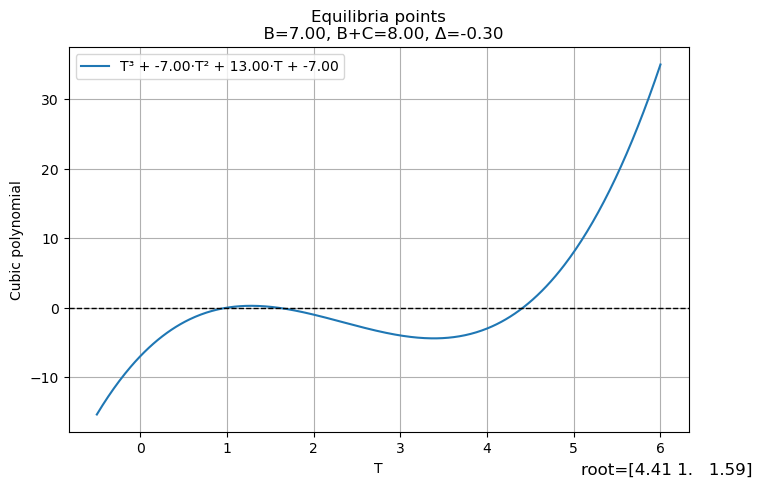

In [31]:
#pour A=1,B=10, C=1
plot_cubics(A=1, B=7, C=1)
plt.savefig('three_roots.png', format = 'png')